In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
iris = load_iris()

X = iris.data
y = iris.target

print("Features Shape:", X.shape)
print("Classes:", np.unique(y))

Features Shape: (150, 4)
Classes: [0 1 2]


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
model = Sequential([
    Dense(16, activation='relu', input_shape=(4,)),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])

c:\Users\paul8\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
optimizer = Adam(learning_rate=0.01)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.3250 - loss: 1.3611 - val_accuracy: 0.3667 - val_loss: 1.0558
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4250 - loss: 1.0548 - val_accuracy: 0.7000 - val_loss: 0.9682
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6500 - loss: 0.9940 - val_accuracy: 0.4000 - val_loss: 0.9774
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7250 - loss: 0.9608 - val_accuracy: 1.0000 - val_loss: 0.9034
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9000 - loss: 0.8858 - val_accuracy: 0.7667 - val_loss: 0.8177
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7167 - loss: 0.8073 - val_accuracy: 0.7000 - val_loss: 0.7257
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6833 - loss: 0.7178 - val_accuracy: 0.7333 - val_loss: 0.6328
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7083 - loss: 0.6281 - val_accuracy: 0.8000 - val_loss: 0.5509


In [8]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 1.0000 - loss: 0.0588
Loss: 0.05881549417972565
Accuracy: 1.0


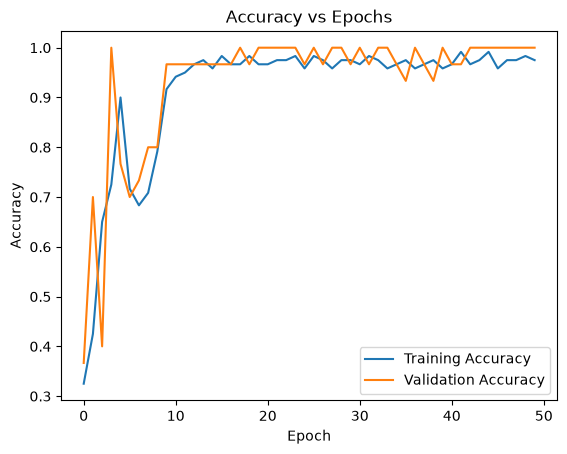

In [9]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")
plt.legend()

plt.show()

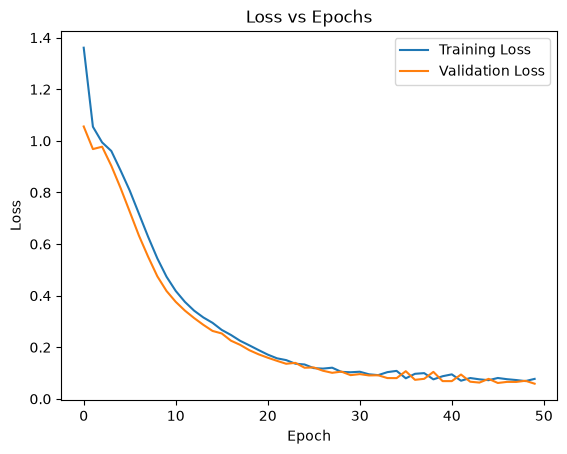

In [10]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()

plt.show()

In [11]:
learning_rates = [0.1, 0.01, 0.001]

for lr in learning_rates:

    model = Sequential([
        Dense(16, activation='relu', input_shape=(4,)),
        Dense(8, activation='relu'),
        Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(X_train, y_train, epochs=30, verbose=0)

    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    print(f"Learning Rate = {lr} --> Accuracy = {acc:.4f}")

Learning Rate = 0.1 --> Accuracy = 0.3000
Learning Rate = 0.01 --> Accuracy = 0.9667
Learning Rate = 0.001 --> Accuracy = 1.0000


In [12]:
epochs_list = [10, 30, 50]

for ep in epochs_list:

    model = Sequential([
        Dense(16, activation='relu', input_shape=(4,)),
        Dense(8, activation='relu'),
        Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.01),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(X_train, y_train, epochs=ep, verbose=0)

    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    print(f"Epochs = {ep} --> Accuracy = {acc:.4f}")

Epochs = 10 --> Accuracy = 0.9667
Epochs = 30 --> Accuracy = 0.9667
Epochs = 50 --> Accuracy = 0.9333
